<table border=1 width="100%"><tr><td bgcolor="#B00A0F">
<h1><font color="#FFFFFF">&nbsp; Selección de Umbrales — Variables Objetivo</font></h1>

</td></tr></table>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

In [17]:
# 1. Cargar el dataset
df = pd.read_csv('BD/bd_liga1_Peru_entrenamiento.csv', sep=';')

# 2. Definir las estadísticas base
columnas_estadisticas = [
    'goles',
    'Goles esperados (xG)',
    'Tiros a puerta'
]

# 3. Desdoblar los datos para los equipos LOCALES
df_local = df[['fecha', 'equipo_local', 'equipo_visitante']].copy()
df_local.columns = ['Fecha', 'Equipo', 'Rival']
df_local['Local'] = 1

for col in columnas_estadisticas:
    df_local[col] = df[f'{col}_local']

# 4. Desdoblar los datos para los equipos VISITANTES
df_visitante = df[['fecha', 'equipo_visitante', 'equipo_local']].copy()
df_visitante.columns = ['Fecha', 'Equipo', 'Rival']
df_visitante['Local'] = 0

for col in columnas_estadisticas:
    df_visitante[col] = df[f'{col}_visitante']

# 5. Unir ambos sub-conjuntos en un solo dataset (formato vertical/pivotado)
df_estructurado = pd.concat([df_local, df_visitante], ignore_index=True)

# 6. Convertir la fecha a formato de tiempo real y ordenar cronológicamente por equipo
df_estructurado['Fecha'] = pd.to_datetime(df_estructurado['Fecha'], format='%d/%m/%Y')
df_estructurado = df_estructurado.sort_values(by=['Equipo', 'Fecha']).reset_index(drop=True)

# 7. Crear los 3 Targets independientes (uno por variable objetivo)
df_estructurado['Target_XG']    = np.where(df_estructurado['Goles esperados (xG)'] >= 1.5, 1, 0)
df_estructurado['Target_Tiros_Puerta'] = np.where(df_estructurado['Tiros a puerta'] >= 5, 1, 0)
df_estructurado['Target_Goles'] = np.where(df_estructurado['goles'] >= 2, 1, 0)

# Verificar el resultado final
print("Dimensiones del nuevo dataset:", df_estructurado.shape)
print("\nMuestra de las variables clave calculadas:")
print(df_estructurado[['Fecha', 'Equipo', 'Rival', 'Local', 'Goles esperados (xG)', 'Tiros a puerta', 'goles', 'Target_XG', 'Target_Tiros_Puerta', 'Target_Goles']].head(5))

Dimensiones del nuevo dataset: (2156, 10)

Muestra de las variables clave calculadas:
       Fecha             Equipo           Rival  Local  Goles esperados (xG)  \
0 2025-02-09  ADC Juan Pablo II      Sport Boys      0                  1.21   
1 2025-02-16  ADC Juan Pablo II  Sport Huancayo      1                  0.55   
2 2025-02-21  ADC Juan Pablo II    Alianza Lima      0                  1.13   
3 2025-03-10  ADC Juan Pablo II      Binacional      0                  0.45   
4 2025-03-30  ADC Juan Pablo II             UTC      1                  3.56   

   Tiros a puerta  goles  Target_XG  Target_Tiros_Puerta  Target_Goles  
0               1      0          0                    0             0  
1               1      0          0                    0             0  
2               4      0          0                    0             0  
3               2      0          0                    0             0  
4               6      4          1                    1            

In [18]:
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Calibri', 'DejaVu Sans'],
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

<table width='90%'>
<tr>
<td bgcolor='#FFBA39'>

## **<font color="#000000"> 1. Variable Objetivo: Goles Esperados</font>**
</td>
</tr>
</table>

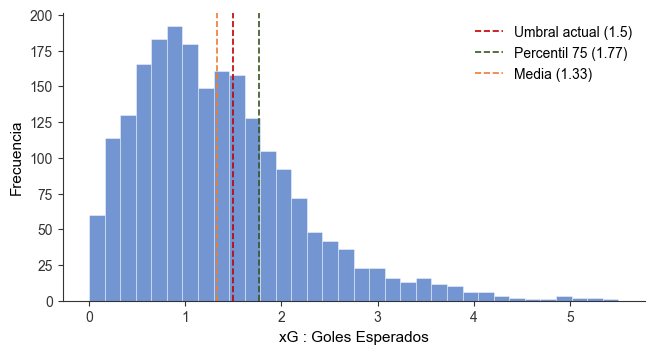

In [19]:
xg = df_estructurado['Goles esperados (xG)']
media = xg.mean()
p75  = xg.quantile(0.75)

fig, ax = plt.subplots(figsize=(6.5, 3.5))

ax.hist(xg, bins='fd', color='#4472C4', alpha=0.75, edgecolor='white', linewidth=0.4)

ax.axvline(1.5,   color='#C00000', linestyle='--', linewidth=1.2,
           label=f'Umbral actual (1.5)')
ax.axvline(p75,   color='#375623', linestyle='--', linewidth=1.2,
           label=f'Percentil 75 ({p75:.2f})')
ax.axvline(media, color='#ED7D31', linestyle='--', linewidth=1.2,
           label=f'Media ({media:.2f})')

ax.set_xlabel('xG : Goles Esperados', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
ax.legend(frameon=False, fontsize=10)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout(pad=0.5)
plt.savefig('distribucion_xg.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()

In [20]:
print("=== Distribución de Tiros a Puerta en Liga 1 ===")
print(xg.describe())

# Tabla comparativa de umbrales para goles esperados
umbrales = [1.0, 1.2, 1.3, 1.5, 1.7, 2.0]

print(f"\n{'Umbral':<10} {'Clase 0':<12} {'Clase 1':<12} {'% Clase 1':<12}")
print("-" * 46)
for u in umbrales:
    y_temp = (df_estructurado['Goles esperados (xG)'] > u).astype(int)
    n0 = (y_temp == 0).sum()
    n1 = (y_temp == 1).sum()
    pct = n1 / len(y_temp) * 100
    marca = " *" if u == 1.5 else ""
    print(f"{u:<10} {n0:<12} {n1:<12} {pct:.1f}%{marca}")

print("\n* Umbral seleccionado (Goles Esperados >= 1.5)")

=== Distribución de Tiros a Puerta en Liga 1 ===
count    2156.000000
mean        1.332945
std         0.851621
min         0.000000
25%         0.700000
50%         1.195000
75%         1.770000
max         5.500000
Name: Goles esperados (xG), dtype: float64

Umbral     Clase 0      Clase 1      % Clase 1   
----------------------------------------------
1.0        874          1282         59.5%
1.2        1086         1070         49.6%
1.3        1183         973          45.1%
1.5        1374         782          36.3% *
1.7        1574         582          27.0%
2.0        1768         388          18.0%

* Umbral seleccionado (Goles Esperados >= 1.5)


<table width='90%'>
<tr>
<td bgcolor='#FFBA39'>

## **<font color="#000000"> 2. Variable Objetivo: Tiros a Puerta </font>**
</td>
</tr>
</table>

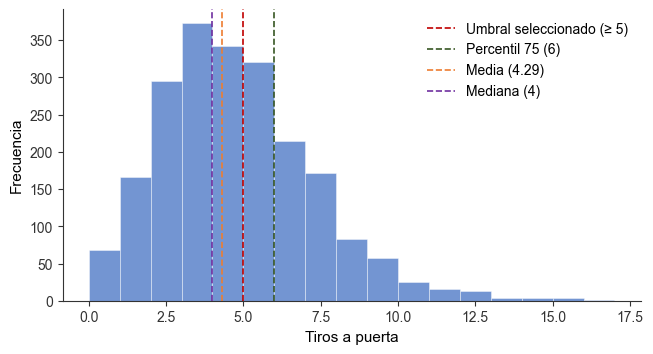

In [21]:
tiros = df_estructurado['Tiros a puerta']
media_t = tiros.mean()
p75_t   = tiros.quantile(0.75)
mediana_t = tiros.median()

fig, ax = plt.subplots(figsize=(6.5, 3.5))

bins=range(0, int(tiros.max()) + 2)

ax.hist(tiros, bins=bins, color='#4472C4', alpha=0.75,
        edgecolor='white', linewidth=0.4)

ax.axvline(5,        color='#C00000', linestyle='--', linewidth=1.2,
           label='Umbral seleccionado (≥ 5)')
ax.axvline(p75_t,    color='#375623', linestyle='--', linewidth=1.2,
           label=f'Percentil 75 ({p75_t:.0f})')
ax.axvline(media_t,  color='#ED7D31', linestyle='--', linewidth=1.2,
           label=f'Media ({media_t:.2f})')
ax.axvline(mediana_t,color='#7030A0', linestyle='--', linewidth=1.2,
           label=f'Mediana ({mediana_t:.0f})')

ax.set_xlabel('Tiros a puerta', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout(pad=0.5)
plt.savefig('distribucion_tiros_puerta.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [22]:
tiros = df_estructurado['Tiros a puerta']

print("=== Distribución de Tiros a Puerta en Liga 1 ===")
print(tiros.describe())

# Tabla comparativa de umbrales para tiros a puerta
umbrales_tiros = [2, 3, 4, 5, 6]
print(f"\n{'Umbral':<10} {'Clase 0':<12} {'Clase 1':<12} {'% Clase 1':<12}")
print("-" * 46)
for u in umbrales_tiros:
    y_temp = (df_estructurado['Tiros a puerta'] >= u).astype(int)
    n0 = (y_temp == 0).sum()
    n1 = (y_temp == 1).sum()
    pct = n1 / len(y_temp) * 100
    marca = " *" if u == 5 else ""
    print(f"{u:<10} {n0:<12} {n1:<12} {pct:.1f}%{marca}")

print("\n* Umbral seleccionado (Tiros a puerta >= 5)")

=== Distribución de Tiros a Puerta en Liga 1 ===
count    2156.000000
mean        4.293599
std         2.471663
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        16.000000
Name: Tiros a puerta, dtype: float64

Umbral     Clase 0      Clase 1      % Clase 1   
----------------------------------------------
2          234          1922         89.1%
3          529          1627         75.5%
4          902          1254         58.2%
5          1244         912          42.3% *
6          1565         591          27.4%

* Umbral seleccionado (Tiros a puerta >= 5)


<table width='90%'>
<tr>
<td bgcolor='#FFBA39'>

## **<font color="#000000"> 3. Variable Objetivo: Goles Anotados </font>**
</td>
</tr>
</table>

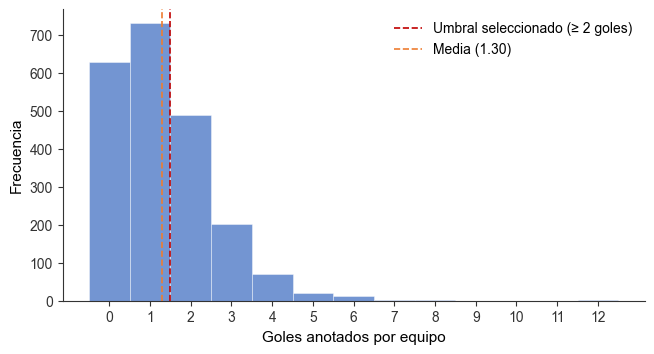

In [23]:
goles = df_estructurado['goles']

fig, ax = plt.subplots(figsize=(6.5, 3.5))

ax.hist(goles, bins=range(0, int(goles.max()) + 2),
        color='#4472C4', alpha=0.75,
        edgecolor='white', linewidth=0.4,
        align='left')

ax.axvline(1.5, color='#C00000', linestyle='--', linewidth=1.2,
           label='Umbral seleccionado (≥ 2 goles)')
ax.axvline(goles.mean(), color='#ED7D31', linestyle='--', linewidth=1.2,
           label=f'Media ({goles.mean():.2f})')

ax.set_xlabel('Goles anotados por equipo', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_xticks(range(0, int(goles.max()) + 1))
ax.legend(frameon=False, fontsize=10)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout(pad=0.5)
plt.savefig('distribucion_goles.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [27]:
print("=== Distribución de Goles en Liga 1 ===")
print(goles.describe())

# Frecuencias absolutas por cantidad de goles
n_total = len(goles)
print(f"\n{'Goles':<12} {'Frecuencia':<12} {'%':<10}")
print("-" * 34)
for val in [0, 1, 2]:
    cnt = (goles == val).sum()
    print(f"{val:<12} {cnt:<12} {cnt/n_total*100:.1f}%")
cnt_3mas = (goles >= 3).sum()
print(f"{'3+':<12} {cnt_3mas:<12} {cnt_3mas/n_total*100:.1f}%")

# Tabla comparativa de umbrales para goles anotados
umbrales_goles = [1, 2, 3, 4]
print(f"\n{'Umbral':<10} {'Clase 0':<12} {'Clase 1':<12} {'% Clase 1':<12}")
print("-" * 46)
for u in umbrales_goles:
    y_temp = (df_estructurado['goles'] >= u).astype(int)
    n0 = (y_temp == 0).sum()
    n1 = (y_temp == 1).sum()
    pct = n1 / len(y_temp) * 100
    marca = " *" if u == 2 else ""
    print(f"{u:<10} {n0:<12} {n1:<12} {pct:.1f}%{marca}")

print("\n* Umbral seleccionado (Goles >= 2)")

=== Distribución de Goles en Liga 1 ===
count    2156.000000
mean        1.301020
std         1.221166
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        12.000000
Name: goles, dtype: float64

Goles        Frecuencia   %         
----------------------------------
0            627          29.1%
1            730          33.9%
2            489          22.7%
3+           310          14.4%

Umbral     Clase 0      Clase 1      % Clase 1   
----------------------------------------------
1          627          1529         70.9%
2          1357         799          37.1% *
3          1846         310          14.4%
4          2049         107          5.0%

* Umbral seleccionado (Goles >= 2)


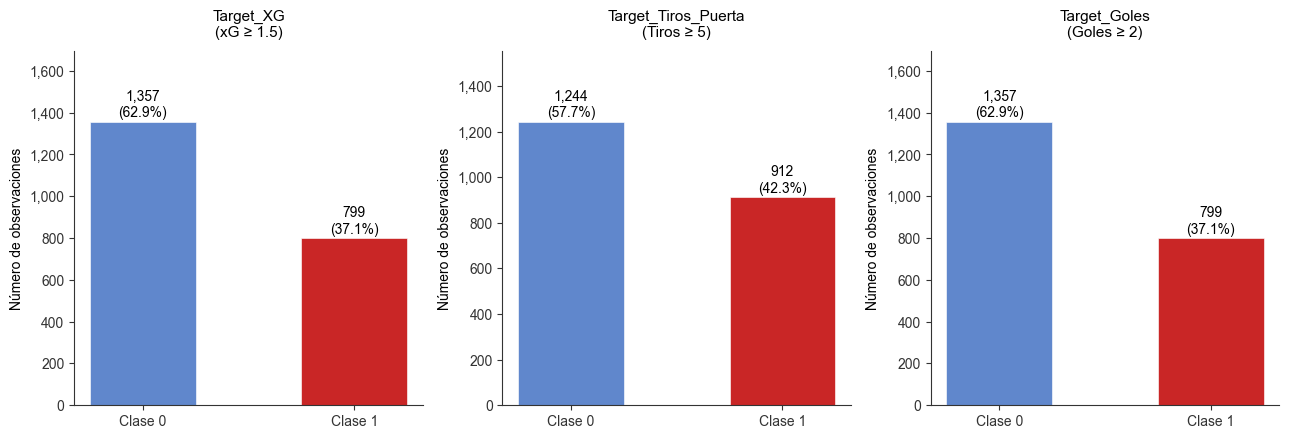


Resumen de distribución de los 3 Targets:
  Target_XG: Clase 0 = 1,357 (62.9%)  |  Clase 1 = 799 (37.1%)
  Target_Tiros_Puerta: Clase 0 = 1,244 (57.7%)  |  Clase 1 = 912 (42.3%)
  Target_Goles: Clase 0 = 1,357 (62.9%)  |  Clase 1 = 799 (37.1%)


In [26]:
targets = {
    'Target_XG\n(xG ≥ 1.5)':       'Target_XG',
    'Target_Tiros_Puerta\n(Tiros ≥ 5)':    'Target_Tiros_Puerta',
    'Target_Goles\n(Goles ≥ 2)':    'Target_Goles',
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)

for ax, (titulo, col) in zip(axes, targets.items()):
    conteo = df_estructurado[col].value_counts().sort_index()
    valores = conteo.values
    total = valores.sum()
    etiquetas = ['Clase 0', 'Clase 1']

    barras = ax.bar(etiquetas, valores,
                    color=['#4472C4', '#C00000'],
                    alpha=0.85, edgecolor='white',
                    linewidth=0.5, width=0.5)

    for barra, val in zip(barras, valores):
        pct = val / total * 100
        ax.text(barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 10,
                f'{val:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=10)

    ax.set_title(titulo, fontsize=11, pad=10)
    ax.set_ylabel('Número de observaciones', fontsize=10)
    ax.set_ylim(0, max(valores) * 1.25)
    ax.tick_params(axis='both', labelsize=10)
    ax.yaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

plt.tight_layout(pad=1.0)
plt.savefig('distribucion_targets.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

print("\nResumen de distribución de los 3 Targets:")
for titulo, col in targets.items():
    n1 = df_estructurado[col].sum()
    n0 = len(df_estructurado) - n1
    print(f"  {col}: Clase 0 = {n0:,} ({n0/len(df_estructurado)*100:.1f}%)  |  Clase 1 = {n1:,} ({n1/len(df_estructurado)*100:.1f}%)")